In [28]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.linalg import eigh
# 1. Simple graph: Define adjacency matrix
AdjMatrix = np.array([[0, 1, 1, 0],
 [1, 0, 0, 1],
 [1, 0, 0, 1],
 [0, 1, 1, 0]])
print("Adjacency Matrix:\n", AdjMatrix)

Adjacency Matrix:
 [[0 1 1 0]
 [1 0 0 1]
 [1 0 0 1]
 [0 1 1 0]]


In [29]:
# 2. Find the row sums of the matrix AdjMatrix
RowSums = np.sum(AdjMatrix, axis=1)
print("\nRow Sums:")
print(RowSums)


Row Sums:
[2 2 2 2]


In [30]:
# 3. Compute the Laplacian of the graph
LaplaceGraph = np.diag(RowSums) - AdjMatrix
print("\nLaplacian Matrix:")
print(LaplaceGraph)
# Check if LaplaceGraph is singular
test_vector = np.ones(len(LaplaceGraph))
singularity_check = LaplaceGraph @ test_vector
print("\nSingularity Check (Laplacian * ones):")
print(singularity_check)



Laplacian Matrix:
[[ 2 -1 -1  0]
 [-1  2  0 -1]
 [-1  0  2 -1]
 [ 0 -1 -1  2]]

Singularity Check (Laplacian * ones):
[0. 0. 0. 0.]


In [31]:
# 4. Find eigenvalues and eigenvectors using the eig function
D, V = np.linalg.eig(LaplaceGraph)


In [32]:
# 5. Sort eigenvalues/eigenvectors
ind = np.argsort(D.real)
D = D.real[ind]
V = V[:, ind].real
print("\nEigenvalues (sorted):")
print(D)
print("\nEigenvectors (sorted columns):")
print(V)


Eigenvalues (sorted):
[-2.22044605e-16  2.00000000e+00  2.00000000e+00  4.00000000e+00]

Eigenvectors (sorted columns):
[[ 5.00000000e-01  4.08248290e-01  7.07106781e-01 -5.00000000e-01]
 [ 5.00000000e-01 -5.77350269e-01  4.80181756e-16  5.00000000e-01]
 [ 5.00000000e-01  5.77350269e-01 -1.77321568e-16  5.00000000e-01]
 [ 5.00000000e-01 -4.08248290e-01 -7.07106781e-01 -5.00000000e-01]]


In [33]:
# 6. Identify the second smallest eigenvalue and its corresponding eigenvector
second_smallest_eigenvalue = D[1]
V2 = V[:, 1]
# Ensure V2 has a positive first entry for consistent sign
if V2[0] < 0:
    V2 = -V2
print("\nSecond Smallest Eigenvalue:")
print(second_smallest_eigenvalue)
print("\nEigenvector corresponding to second smallest eigenvalue:")
print(V2)


Second Smallest Eigenvalue:
1.9999999999999991

Eigenvector corresponding to second smallest eigenvalue:
[ 0.40824829 -0.57735027  0.57735027 -0.40824829]



Positive Indices (V2 > 0):
[0, 2]

Negative Indices (V2 <= 0):
[1, 3]


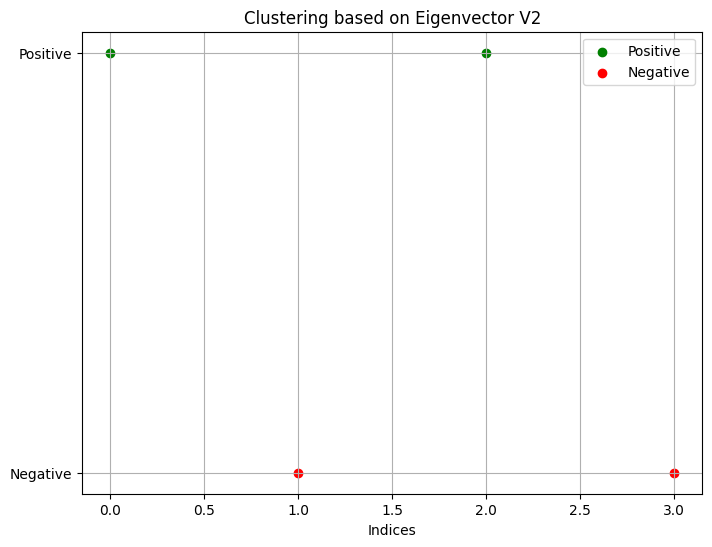

In [34]:
# 7. Separate the elements of the eigenvector V2
pos = []
neg = []
for j in range(len(V2)):
    if V2[j] > 0:
        pos.append(j)
    else:
        neg.append(j)
print("\nPositive Indices (V2 > 0):")
print(pos)
print("\nNegative Indices (V2 <= 0):")
print(neg)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(pos, [1] * len(pos), color='green', label='Positive')
plt.scatter(neg, [0] * len(neg), color='red', label='Negative')
plt.yticks([0, 1], ['Negative', 'Positive'])
plt.title('Clustering based on Eigenvector V2')
plt.xlabel('Indices')
plt.legend()
plt.grid()
plt.show()

In [35]:
# code for creating a social.mat file

import numpy as np
from scipy.io import savemat

# Create a 351x351 random block-diagonal matrix to simulate two communities
size = 351
Social = np.zeros((size, size))

# Fill two dense blocks (communities)
Social[:175, :175] = np.random.rand(175, 175) < 0.3
Social[175:, 175:] = np.random.rand(176, 176) < 0.3

# Add some sparse noise (connections between communities)
Social += np.random.rand(size, size) < 0.01

# Make it symmetric and remove diagonal (no self-friends)
Social = np.maximum(Social, Social.T)
np.fill_diagonal(Social, 0)

# Save as .mat
savemat("social.mat", {"Social": Social.astype(float)})

Loaded Social adjacency matrix with shape: (351, 351)


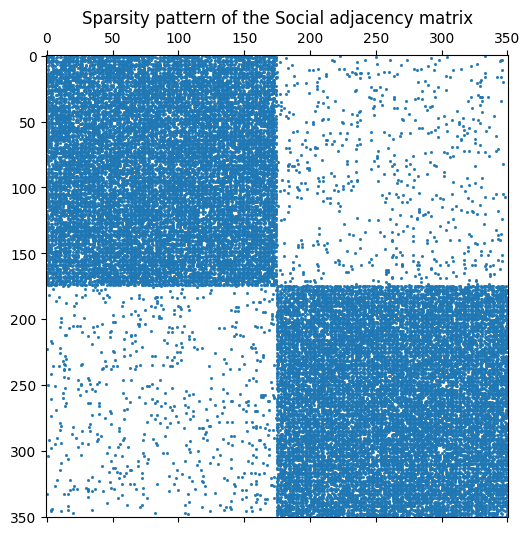

In [36]:
from scipy.io import loadmat
# 8. Load the data
data =loadmat("./social.mat")
Social = data['Social']
print("Loaded Social adjacency matrix with shape:", Social.shape)

# Spy plot of the Social matrix
plt.figure(figsize=(8, 6))
plt.spy(Social, markersize=1)
plt.title('Sparsity pattern of the Social adjacency matrix')
plt.show()

In [37]:
# 9. Define DiagSocial and LaplaceSocial
DiagSocial = np.sum(Social, axis=1)
LaplaceSocial = np.diag(DiagSocial) - Social
print("\nDiagonal matrix DiagSocial:")
print(DiagSocial)
print("\nLaplacian matrix LaplaceSocial:")
print(LaplaceSocial)


Diagonal matrix DiagSocial:
[ 92. 102.  84.  95.  88.  86.  95.  89.  86.  93.  95. 103.  96.  89.
  96.  98. 104. 101.  92.  89. 101.  90. 102.  87.  96.  84.  87.  97.
  97.  89.  90.  95.  89.  88.  94.  99.  78.  87.  95.  91. 104.  96.
 103. 100.  90.  93.  89.  97.  90. 111.  91.  82. 101. 103.  85.  89.
  90.  88.  89.  98.  98.  84.  96.  96.  95.  87. 104.  94.  95.  95.
 101.  87. 107.  96.  96. 100.  85.  94.  90.  96.  95.  86.  97.  90.
 101.  97.  93.  94.  95.  96.  90.  80.  95.  89. 100. 103.  95.  93.
 101.  84. 104.  95. 104.  85. 102.  93.  99.  94. 102.  90. 103.  88.
  95.  84.  99.  98. 102.  99.  84. 106. 101. 103.  82.  97. 105.  88.
  87.  85.  89.  82. 102.  95.  91. 104. 102.  98. 106.  93.  88. 102.
 109.  92.  99.  85.  88.  88.  84.  88. 110. 106.  86.  91.  97.  96.
  94.  93. 103. 100. 105. 117.  91.  93. 101.  91. 103. 100.  98. 104.
  88. 112. 101. 103.  91. 111.  88. 101.  91.  87.  94.  93.  95.  99.
  83. 105. 111.  88. 102.  98.  96.  95. 102.  8

In [38]:
# 10. Compute eigenvalues and eigenvectors
D, V = np.linalg.eig(LaplaceSocial)
print("\nEigenvalues (D):")
print(D)
print("\nEigenvectors (V):")
print(V)
# Check the shapes
print("Shape of V (eigenvectors):", V.shape)
print("Shape of D (eigenvalues):", D.shape)
d, ind = np.argsort(D), np.argsort(D)
D = np.diag(D[ind])
V = V[:, ind]
print("\nEigenvalues (sorted):")
print(np.diag(D))
print("\nEigenvectors (sorted):")
print(V)


Eigenvalues (D):
[8.88178420e-16 6.81579158e+00 1.20619936e+02 7.33658846e+01
 1.17698360e+02 1.16934098e+02 7.51563591e+01 1.16193051e+02
 7.59340652e+01 7.65361309e+01 7.68757735e+01 7.71539160e+01
 7.74247314e+01 7.76532648e+01 7.77727482e+01 7.80001919e+01
 7.83700619e+01 7.84300534e+01 7.86020981e+01 7.89184109e+01
 7.92237526e+01 7.90689132e+01 1.15506211e+02 1.15057086e+02
 1.14861609e+02 1.14685242e+02 1.14547400e+02 1.14025870e+02
 1.13682400e+02 1.13335040e+02 1.13303819e+02 1.12468894e+02
 1.12247600e+02 1.12029255e+02 1.11921727e+02 1.11537411e+02
 1.11630375e+02 1.11608007e+02 1.11195846e+02 1.11001551e+02
 1.10872028e+02 1.10588438e+02 1.10497090e+02 1.10379733e+02
 1.10176772e+02 1.10089045e+02 1.09955346e+02 1.09790185e+02
 1.09594475e+02 1.09509771e+02 7.94881851e+01 7.96584522e+01
 7.97689287e+01 8.00256831e+01 8.00692725e+01 8.04065356e+01
 8.04910174e+01 8.06385922e+01 8.11904574e+01 8.08487029e+01
 8.09072329e+01 8.09618023e+01 8.10649157e+01 1.09351871e+02
 1.092

In [39]:
second_smallest_eigenvalue = D[1, 1]
V2 = V[:, 1]
# Ensure V2 has a positive first entry
if V2[0] < 0:
 V2 = -V2
print("\nSecond Smallest Eigenvalue:")
print(second_smallest_eigenvalue)
print("\nEigenvector corresponding to the second smallest eigenvalue (V2):")
print(V2)
pos = []
neg = []
for j in range(len(V2)):
 if V2[j] > 0:
    pos.append(j)
 else:
    neg.append(j)
print("\nPositive Indices (V2 > 0):")
print(pos)
print("\nNegative Indices (V2 <= 0):")
print(neg)



Second Smallest Eigenvalue:
6.8157915841786485

Eigenvector corresponding to the second smallest eigenvalue (V2):
[ 0.05546698  0.05467516  0.05544065  0.04947074  0.05525314  0.05512497
  0.05391989  0.05506387  0.05557023  0.05515895  0.05061808  0.05062513
  0.05281694  0.05147028  0.05172937  0.05159652  0.05067865  0.05491765
  0.05540912  0.05687993  0.05293325  0.05446085  0.053978    0.0551586
  0.05388608  0.05549046  0.05289511  0.05182146  0.05636173  0.05522378
  0.05542381  0.04699898  0.05536274  0.05274157  0.05035433  0.05522908
  0.0572057   0.05380153  0.05172766  0.05505085  0.05091643  0.05404522
  0.05411091  0.05375466  0.05278066  0.05528496  0.05405379  0.05382901
  0.05286304  0.05110938  0.05178914  0.0554999   0.05259051  0.0551318
  0.05551533  0.05430762  0.05535448  0.0524908   0.05130369  0.04892345
  0.05423721  0.05385394  0.05631686  0.05153428  0.05041271  0.05701556
  0.05615976  0.05281757  0.05395513  0.05272378  0.05174376  0.05401726
  0.0518918

In [40]:
# Create the order based on positive and negative indices
order = pos + neg # Combine the positive and negative indices
m, n = Social.shape # Get the shape of the Social matrix
iden = np.eye(m) # Identity matrix of size m
# Create the permutation matrix P

P = np.zeros((m, m))
for j in range(m):
 for k in range(m):
    P[j, k] = iden[order[j], k]
# Permute the adjacency matrix
SocialOrdered = P @ Social @ P.T # Using matrix multiplication
print("Shape of SocialOrdered:", SocialOrdered.shape)


Shape of SocialOrdered: (351, 351)


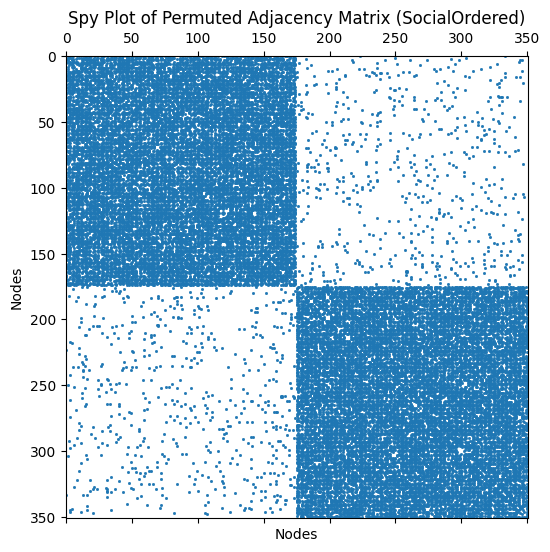

In [41]:
import matplotlib.pyplot as plt
# Plot the permuted adjacency matrix
plt.figure(figsize=(8, 6))
plt.spy(SocialOrdered, markersize=1) # Using a smaller marker size for better visibility
plt.title("Spy Plot of Permuted Adjacency Matrix (SocialOrdered)")
plt.xlabel("Nodes")
plt.ylabel("Nodes")
plt.grid(False) # Disable the grid
plt.show()

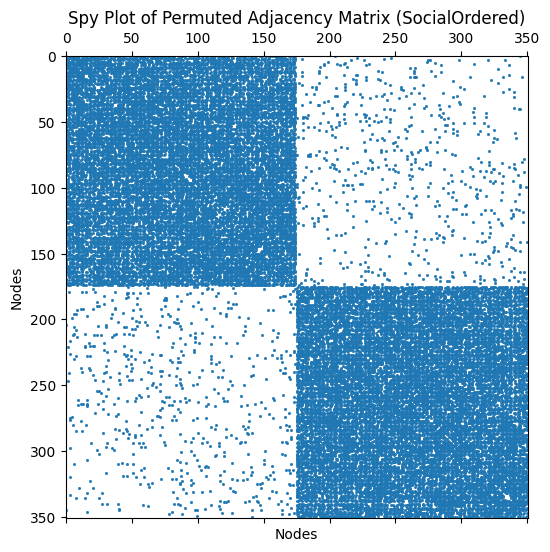

In [42]:
# 14. Cluster in 4 groups using V2 and V3

# Explore the third smallest eigenvector
V3 = V[:, 2]
if V3[0] < 0:
    V3 = -V3

# Initialize 4 sign-based groups
pp = []  # V2>0, V3>0
pn = []  # V2>0, V3<=0
np_group = []  # V2<=0, V3>0
nn = []  # V2<=0, V3<=0

# Group nodes based on signs of V2 and V3
for j in range(len(V2)):
    if V2[j] > 0:
        if V3[j] > 0:
            pp.append(j)
        else:
            pn.append(j)
    else:
        if V3[j] > 0:
            np_group.append(j)
        else:
            nn.append(j)

# Combine group ordering
order = pp + pn + np_group + nn
m = len(Social)
iden = np.eye(m)
P = np.zeros((m, m))

# Create permutation matrix
for j in range(m):
    P[j, :] = iden[order[j], :]

# Permute adjacency matrix
SocialOrdered = P @ Social @ P.T

# Plot permuted matrix
plt.figure(figsize=(8, 6))
plt.spy(SocialOrdered, markersize=1)
plt.title("Spy Plot of Permuted Adjacency Matrix (SocialOrdered)")
plt.xlabel("Nodes")
plt.ylabel("Nodes")
plt.grid(False)
plt.show()

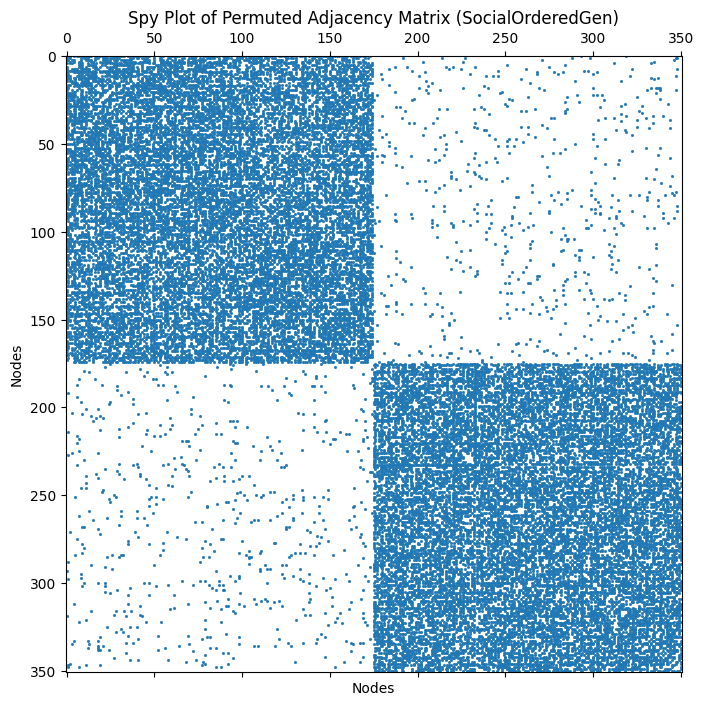

In [43]:
# 15. Fiedler vector procedure iteratively for clusters

# Build subgraphs from the initial two-way split
SocialPos = Social[np.ix_(pos, pos)]
SocialNeg = Social[np.ix_(neg, neg)]

# Positive block: Laplacian + eigendecomposition
rowsumpos = np.sum(SocialPos, axis=1)
DiagSocialPos = np.diag(rowsumpos)
LaplaceSocialPos = DiagSocialPos - SocialPos
DPos, VPos = np.linalg.eig(LaplaceSocialPos)
ind_pos = np.argsort(DPos.real)
DPos = np.diag(DPos.real[ind_pos])
VPos = VPos[:, ind_pos].real
V2Pos = VPos[:, 1]

# Split nodes from positive block
posp = []
posn = []
for j in range(len(V2Pos)):
    if V2Pos[j] > 0:
        posp.append(pos[j])
    else:
        posn.append(pos[j])

# Negative block: Laplacian + eigendecomposition
rowsumneg = np.sum(SocialNeg, axis=1)
DiagSocialNeg = np.diag(rowsumneg)
LaplaceSocialNeg = DiagSocialNeg - SocialNeg
DNeg, VNeg = np.linalg.eig(LaplaceSocialNeg)
ind_neg = np.argsort(DNeg.real)
DNeg = np.diag(DNeg.real[ind_neg])
VNeg = VNeg[:, ind_neg].real
V2Neg = VNeg[:, 1]

# Split nodes from negative block
negp = []
negn = []
for j in range(len(V2Neg)):
    if V2Neg[j] > 0:
        negp.append(neg[j])
    else:
        negn.append(neg[j])

# Build final permutation order
ordergen = posp + posn + negp + negn
m = len(Social)
iden = np.eye(m)
P = np.zeros((m, m))
for j in range(m):
    P[j, :] = iden[ordergen[j], :]

# Permute and visualize
SocialOrderedGen = P @ Social @ P.T
plt.figure(figsize=(10, 8))
plt.spy(SocialOrderedGen, markersize=1)
plt.title("Spy Plot of Permuted Adjacency Matrix (SocialOrderedGen)")
plt.xlabel("Nodes")
plt.ylabel("Nodes")
plt.grid(False)
plt.show()